# Mutual Fund Analysis and Prediction

# Big Data Fundamentals Assignment

# Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import silhouette_samples,silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score


# Dataset

## Loading Data

In [2]:
# Loading the Mutual Fund dataset

df_mfs = pd.read_excel("Mutual Funds Analysis and Prediction.xlsx")

## Creation of new columns

### New Column: Creating column 'Fund Type' - Equity, Hybrid, Debt, Fund of Funds, Gold 

In [3]:
# Adding a column 'FundType' to display different type of Mutual Fund types - Equity, Hybrid, Debt, Fund of Funds, Gold

conditions = [df_mfs['classification'].str.contains("FoFs"), df_mfs['classification'].str.contains("Hybrid"), 
              df_mfs['classification'].str.contains("Equity"), df_mfs['classification'].str.contains("Debt"), 
              df_mfs['classification'].str.contains("Gold")]
values = ['Fund of Funds', 'Hybrid', 'Equity', 'Debt', 'Gold']
df_mfs['FundType'] = np.select(conditions, values)    

### New Column: Creating column Fund Category 

In [4]:
# Adding a column 'Fund Category' to display different type of categories under each type. For e.g Equity Fund 
# type will have Large Cap, Mid Cap & Small cap as different categories

df_mfs['position'] = df_mfs['classification'].str.find(':')
df_mfs['Fund Category'] = df_mfs.apply(lambda x: x['classification'][x['position'] + 2:len(x['classification'])],axis=1)

In [5]:
df_mfs.head()

,Fund House,Funds,Fund Manager,Category,Rating,AUM(in Rs. cr),ExpenseRatio (%),Inception Date,Benchmark Index,NAV,...,Sortino,Beta,Standard Deviation,classification,category_average_return_1year,category_average_return_3years,Exit_load_Remarks,FundType,position,Fund Category
0,Aditya Birla Sun Life,Aditya Birla SL Active Debt Multi-Mgr FoF(G),Kaustubh Gupta,FOF-DOM,Unrated,9.7,0.62,2006-12-28 00:00:00,Crisil Composite Bond Fund Index,30.72,...,-0.62,0.17,0.99,FoFs : Domestic,-3.72,13.95,0.25% on or before 15D Nil after 15D,Fund of Funds,5,Domestic
1,Aditya Birla Sun Life,Aditya Birla SL Arbitrage Fund(G),Lovelish Solanki,HY-ARB,3,5348.8,1.03,2009-07-24 00:00:00,Nifty 50 Arbitrage,22.06,...,2.03,-0.01,0.88,Hybrid : Arbitrage,3.56,3.65,0.25% on or before 30D Nil after 30D,Hybrid,7,Arbitrage
2,Aditya Birla Sun Life,Aditya Birla SL Asset Allocator FoF(G),Vinod Narayan Bhat,FOF-DOM,Unrated,142.2,1.6,2006-08-17 00:00:00,CRISIL Hybrid 50+50 - Moderate Index,42.99,...,-0.98,0.44,7.52,FoFs : Domestic,-3.72,13.95,1% on or before 365D Nil after 365D,Fund of Funds,5,Domestic
3,Aditya Birla Sun Life,Aditya Birla SL Bal Bhavishya Yojna-Reg(G),Atul Penkar,HY-SOL,2,614.5,2.48,2019-02-11 00:00:00,NIFTY 500 - TRI,13.59,...,-0.61,1.03,16.61,Hybrid : Solution Oriented,-1.53,19.02,Nil,Hybrid,7,Solution Oriented
4,Aditya Birla Sun Life,Aditya Birla SL Balanced Advantage Fund(G),Mohit Sharma,HY-DYN,4,6745.2,1.81,2000-04-25 00:00:00,CRISIL Hybrid 50+50 - Moderate Index,74.3,...,-0.5,0.54,8.35,Hybrid : Dynamic Asset Allocation,1.18,10.47,0.25% on or before 7D Nil after 7D,Hybrid,7,Dynamic Asset Allocation


In [6]:
df_mfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Fund House                      1294 non-null   object 
 1   Funds                           1294 non-null   object 
 2   Fund Manager                    1294 non-null   object 
 3   Category                        1294 non-null   object 
 4   Rating                          1294 non-null   object 
 5   AUM(in Rs. cr)                  1294 non-null   object 
 6   ExpenseRatio (%)                1294 non-null   object 
 7   Inception Date                  1294 non-null   object 
 8   Benchmark Index                 1294 non-null   object 
 9   NAV                             1294 non-null   object 
 10  52 WeekHigh (NAV)               1294 non-null   object 
 11  52 WeekLow (NAV)                1294 non-null   object 
 12  Return (%)1 mo                  12

## Null values and Data Type conversion

In [7]:
# Replace '-' values with null values and the applying the correct data types

df_mfs = df_mfs.mask(df_mfs =='-')
df_mfs = df_mfs.convert_dtypes()

In [8]:
#Check for the new data types

df_mfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Fund House                      1294 non-null   string        
 1   Funds                           1294 non-null   string        
 2   Fund Manager                    1294 non-null   string        
 3   Category                        1294 non-null   string        
 4   Rating                          1294 non-null   object        
 5   AUM(in Rs. cr)                  1259 non-null   Float64       
 6   ExpenseRatio (%)                1239 non-null   Float64       
 7   Inception Date                  1274 non-null   datetime64[ns]
 8   Benchmark Index                 1294 non-null   string        
 9   NAV                             1279 non-null   Float64       
 10  52 WeekHigh (NAV)               1279 non-null   Float64       
 11  52 W

## Mutual Fund Age: Selecting only funds opened till December 2020 (age > 22 months)

In [9]:
df_mfs = df_mfs[df_mfs["Inception Date"] < '2021-01-01']

## Missing values and Outliers

### Finding missing value percentages for each column

In [10]:
# Function to find missing value percentage in the dataframe

def find_missing_values_percentage(df):
    missing_percent = round(df.isna().mean() * 100, 1)
    return pd.DataFrame(missing_percent[missing_percent > 0], columns=['% of Missing Values'])

In [11]:
# Execute the function to find missing value percentages

find_missing_values_percentage(df_mfs)

,% of Missing Values
ExpenseRatio (%),1.1
Return (%)1 yr,3.2
Return (%)2 yrs,13.6
Return (%)3 yrs,19.7
Return (%)5 yrs,33.7
Return (%)10 yrs,48.8
Turnover Ratio (%),10.6
No. of Stocks,39.1
Avg. Market Cap(in Rs. cr),41.9
Large Cap(%),42.8


### Dropping columns which has more than 30% missing values

In [12]:
df_mfs.drop(['Return (%)5 yrs', 'Return (%)10 yrs', 'Avg. Market Cap(in Rs. cr)', 'Mod. Duration(in yrs)', 
             'Yield To Maturity (%)'], axis = 1, inplace = True)

### Dropping additional columns which are  not required

In [13]:
df_mfs.drop(['Category', 'position'], axis = 1, inplace = True)

### Check if missing values can be replaced using mean/median values

C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Return (%)3 yrs'>

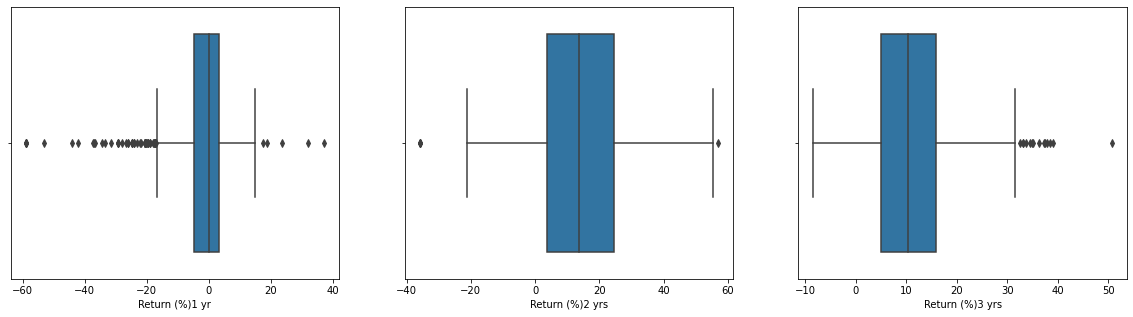

In [14]:
# To check if missing values can be replaced using mean/median values of that feature column

plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(df_mfs['Return (%)1 yr'])
plt.subplot(1,3,2)
sns.boxplot(df_mfs['Return (%)2 yrs'])
plt.subplot(1,3,3)
sns.boxplot(df_mfs['Return (%)3 yrs'])

In [15]:
# Filling missing values with median to mitigate outliers. 
# After replacing the missing values, no change in the pattern of the data in the respective column was observed

df_mfs['Return (%)1 yr'] = df_mfs['Return (%)1 yr'].fillna(df_mfs['Return (%)1 yr'].median())
df_mfs['Return (%)2 yrs'] = df_mfs['Return (%)2 yrs'].fillna(df_mfs['Return (%)2 yrs'].median())
df_mfs['Return (%)3 yrs'] = df_mfs['Return (%)3 yrs'].fillna(df_mfs['Return (%)3 yrs'].median())


##### Outliers were retained as they were legitimate financial data

In [16]:
# Checking outlier data. Outliers were retained as it was legitimate financial data

display(df_mfs[df_mfs['Return (%)1 yr'] < -20]) #| df_mfs['Return (%)1 yr'] > 19]])

,Fund House,Funds,Fund Manager,Rating,AUM(in Rs. cr),ExpenseRatio (%),Inception Date,Benchmark Index,NAV,52 WeekHigh (NAV),...,Sharpe,Sortino,Beta,Standard Deviation,classification,category_average_return_1year,category_average_return_3years,Exit_load_Remarks,FundType,Fund Category
11,Aditya Birla Sun Life,Aditya Birla SL Credit Risk Fund-Segregated Po...,Sunaina da Cunha,Unrated,66.4,<NA>,2019-11-25,NIFTY Credit Risk Bond Index,0.16,0.4,...,-1.08,-1.08,0.07,61.49,Debt : Credit Risk,3.6,5.53,<NA>,Debt,Credit Risk
21,Aditya Birla Sun Life,Aditya Birla SL Dynamic Bond Fund-Segregated P...,Mohit Sharma,Unrated,50.1,<NA>,2019-11-25,NIFTY Composite Debt Index,0.4,0.97,...,-1.08,-1.08,0.08,61.48,Debt : Dynamic Bond,2.02,5.08,<NA>,Debt,Dynamic Bond
22,Aditya Birla Sun Life,Aditya Birla SL Dynamic Bond Fund-Segregated P...,Mohit Sharma,Unrated,50.1,<NA>,2019-11-25,NIFTY Composite Debt Index,0.57,1.4,...,-1.08,-1.08,0.07,61.49,Debt : Dynamic Bond,2.02,5.08,<NA>,Debt,Dynamic Bond
36,Aditya Birla Sun Life,Aditya Birla SL Global Excellence Equity FoF(G),Vinod Narayan Bhat,Unrated,138.7,1.29,2007-12-31,MSCI World,19.14,25.79,...,-0.95,-1.64,0.39,24.32,FoFs : Overseas,-21.18,4.44,0.25% on or before 28D Nil after 28D,Fund of Funds,Overseas
48,Aditya Birla Sun Life,Aditya Birla SL Medium Term Plan-Segregated Po...,Sunaina da Cunha,1,130.7,<NA>,2019-11-25,CRISIL Medium Term Debt Index,0.55,1.33,...,-1.08,-1.08,0.08,61.49,Debt : Medium Duration,1.38,5.02,<NA>,Debt,Medium Duration
49,Aditya Birla Sun Life,Aditya Birla SL Mfg. Equity Fund-Reg(G),Anil Shah,4,662.6,2.51,2015-02-03,S&P BSE India Manufacturing Index - TRI,19.4,20.77,...,-0.59,-0.9,0.81,17.41,Equity : Thematic - Consumption,7.84,17.57,1% on or before 90D Nil after 90D,Equity,Thematic - Consumption
71,Aditya Birla Sun Life,Aditya Birla SL Nifty Smallcap 50 Index Fund-R...,Lovelish Solanki,Unrated,42.1,1.01,2021-04-05,Nifty Smallcap 50 - TRI,10.54,13.57,...,-1.11,-1.62,1.05,24.87,Equity : Index Funds,-2.76,15.7,0.50% on or before 15D Nil after 15D,Equity,Index Funds
111,Axis Mutual Fund,Axis Global Innovation FoF-Reg(G),Hitesh Das,Unrated,1127.6,1.6,2021-05-28,MSCI AC World Index,8.12,11.15,...,-1.17,-1.9,-0.14,26.49,FoFs : Overseas,-21.18,4.44,Nil upto 10% of investment and 1% for remainin...,Fund of Funds,Overseas
114,Axis Mutual Fund,Axis Greater China Equity FoF-Reg(G),Hitesh Das,Unrated,102.3,1.58,2021-02-10,MSCI Golden Dragon Index (Total Return Net),6.22,9.02,...,-1.46,-2.53,-0.28,24.92,FoFs : Overseas,-21.18,4.44,Nil for 10% of investments and 1% for remainin...,Fund of Funds,Overseas
130,Axis Mutual Fund,Axis NIFTY IT ETF,Jinesh Gopani,Unrated,27.5,0.2,2021-03-25,NIFTY IT - TRI,288.65,398.43,...,-0.86,-1.32,1.02,24.85,Equity : ETFs,-3.32,12.35,<NA>,Equity,ETFs


C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\aksha\anaconda3\lib\si

<AxesSubplot:xlabel='Standard Deviation'>

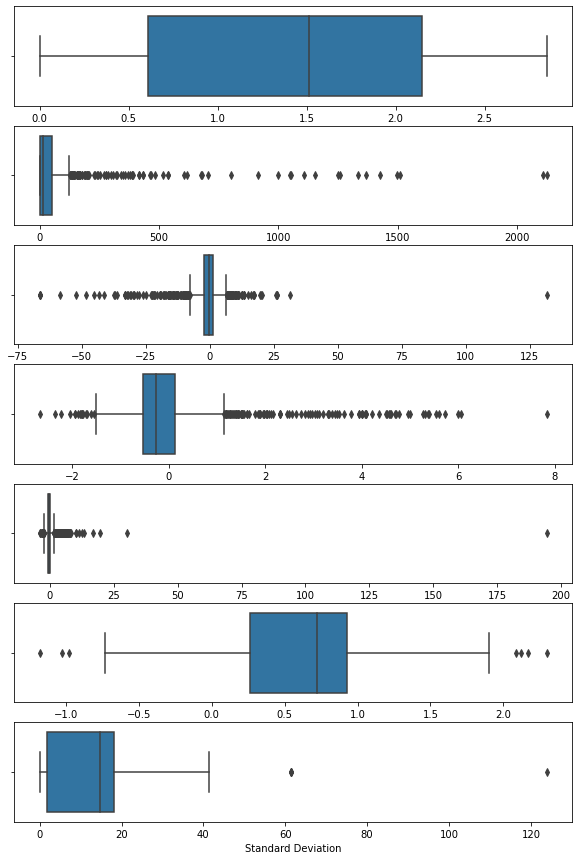

In [17]:
# To check if missing values can be replaced using mean/median values of that feature column

# Checking outlier data. Outliers were retained as they are legitimate financial data

plt.figure(figsize=(10,15))
plt.subplot(7,1,1)
sns.boxplot(df_mfs['ExpenseRatio (%)'])
plt.subplot(7,1,2)
sns.boxplot(df_mfs['Turnover Ratio (%)'])
plt.subplot(7,1,3)
sns.boxplot(df_mfs['Alpha'])
plt.subplot(7,1,4)
sns.boxplot(df_mfs['Sharpe'])
plt.subplot(7,1,5)
sns.boxplot(df_mfs['Sortino'])
plt.subplot(7,1,6)
sns.boxplot(df_mfs['Beta'])
plt.subplot(7,1,7)
sns.boxplot(df_mfs['Standard Deviation'])

In [18]:
# Filling missing values with median to mitigate outliers
# After replacing the missing values, no change in the pattern of the data in the respective column was observed

df_mfs['ExpenseRatio (%)'] = df_mfs['ExpenseRatio (%)'].fillna(df_mfs['ExpenseRatio (%)'].median())
df_mfs['Turnover Ratio (%)'] = df_mfs['Turnover Ratio (%)'].fillna(df_mfs['Turnover Ratio (%)'].median())
df_mfs['Alpha'] = df_mfs['Alpha'].fillna(df_mfs['Alpha'].median())
df_mfs['Sharpe'] = df_mfs['Sharpe'].fillna(df_mfs['Sharpe'].median())
df_mfs['Sortino'] = df_mfs['Sortino'].fillna(df_mfs['Sortino'].median())
df_mfs['Beta'] = df_mfs['Beta'].fillna(df_mfs['Beta'].median())
df_mfs['Standard Deviation'] = df_mfs['Standard Deviation'].fillna(df_mfs['Standard Deviation'].median())


# Data Exploration

In [21]:
# Generate a bar plot showing the count of funds by Fund category under each type (Equity, Debt, Hybrid, FoFs, Gold)

def bucket_by_category(df):
    '''
    Arguments:
        df: dataframe
              
    '''

    fund_cat_count=df_mfs['Fund Category'].value_counts()
    x=fund_cat_count.values
    y=fund_cat_count.index
    fig, ax = plt.subplots(figsize=(10, 15))
    sns.barplot(x,y, ax=ax)
    plt.title('Funds Distribution by Fund Category')
    plt.tight_layout
    plt.show()
    

C:\Users\aksha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


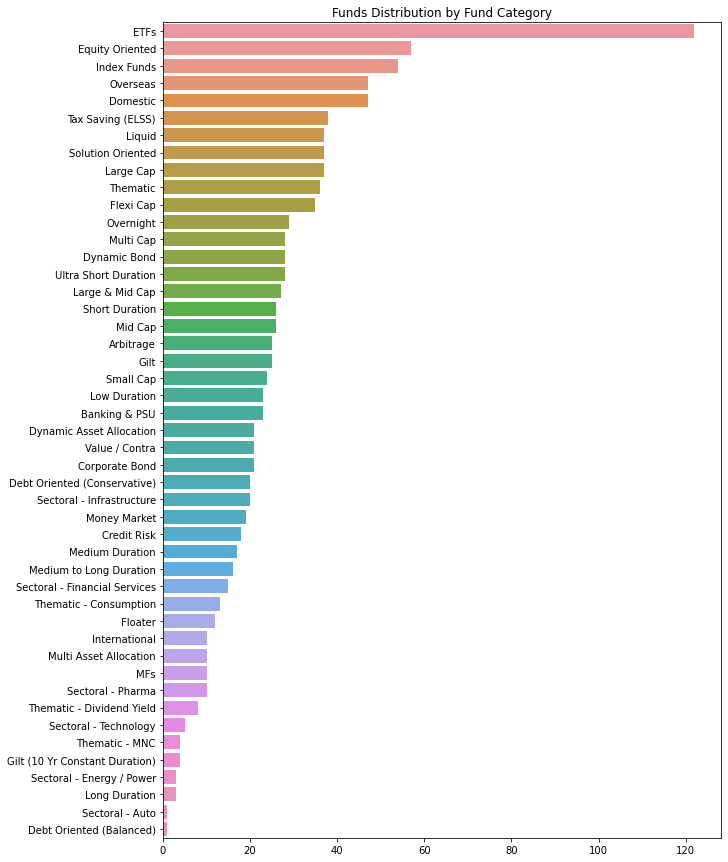

In [22]:
# Generates Figure 3.1

bucket_by_category(df_mfs)

In [23]:
# Creates a pie chart representing the distribution of funds across different fund types (Equity, Debt, Fund of Funds, Gold)

def pie_chart(df,column,title):
    '''
    Arguments:
        df: Pandas dataframe
        column: Type of distribution
        title:Title of pie chart
               
    '''
    x=df.groupby(column).Funds.count()

    fig, ax = plt.subplots(figsize = (15,5))
    fig = ax.pie(x,labels=x.index.to_numpy(),autopct='%.2f%%')
    ax.set_title(title)
    plt.tight_layout()

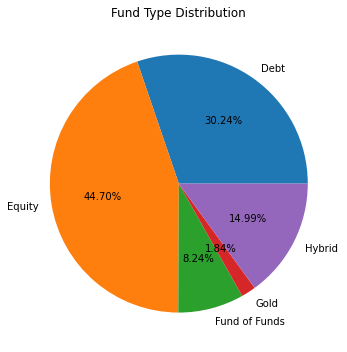

In [24]:
# Generates Figure 3.2

pie_chart(df_mfs, 'FundType', 'Fund Type Distribution')

In [25]:
# Generate a bar plot showing the AUM (Assets under Management - Total market value of the investments) managed 
# by each fund house (companies owning the funds)

def aum_by_fundhouse(df):
    '''
    Arguments
    df: dataframe of funds containing category type.
    
    '''
    
    df = df.groupby(["Fund House"])["AUM(in Rs. cr)"].sum()
    df.plot(kind='bar', title='Total AUM managed by each Fund House',
               ylabel='Total AUM', xlabel='Fund House', figsize=(15, 10))
    
    

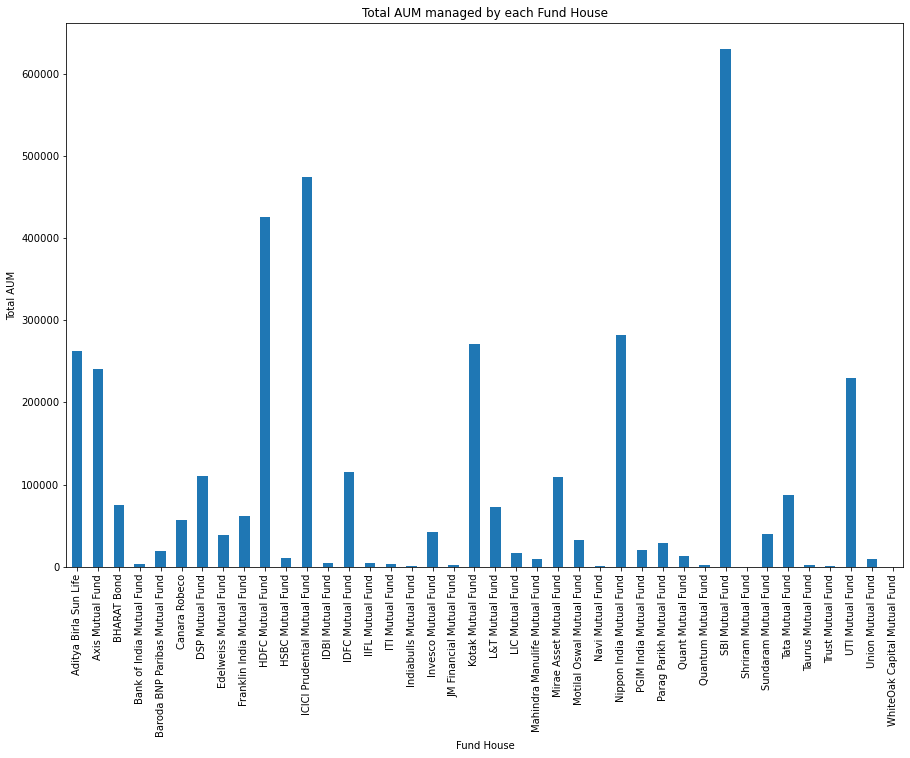

In [26]:
# Generates Figure 3.3

aum_by_fundhouse(df_mfs)

In [27]:
# As seen in the above plot, the top 8 Fund houses manage the most AUM between them. So, further drilling down on these to 
# show the different type of funds managed each of them

def fund_type_by_fundhouse(df):
    '''
    Arguments
    df: dataframe of funds

    '''
    newdf = df.loc[(df["Fund House"] == 'Aditya Birla Sun Life') | (df["Fund House"] == 'Axis Mutual Fund') | 
                   (df["Fund House"] == 'HDFC Mutual Fund') | (df["Fund House"] == 'ICICI Prudential Mutual Fund') | 
                   (df["Fund House"] == 'Kotak Mutual Fund') | (df["Fund House"] == 'Nippon India Mutual Fund') | 
                   (df["Fund House"] == 'SBI Mutual Fund') | (df["Fund House"] == 'UTI Mutual Fund')]
    
    X = ['Aditya Birla Sun Life', 'Axis Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential Mutual Fund', 'Kotak Mutual Fund', 
         'Nippon India Mutual Fund', 'SBI Mutual Fund', 'UTI Mutual Fund']
    
    x = np.arange(len(X))
    width = 0.25
    
    fig = plt.figure(figsize=(20,5))
    ax = fig.add_subplot(111)
    
    a = newdf[newdf.FundType == 'Equity'].groupby(["Fund House"])["FundType"].count()
    b = newdf[newdf.FundType == 'Debt'].groupby(["Fund House"])["FundType"].count()
    c = newdf[newdf.FundType == 'Hybrid'].groupby(["Fund House"])["FundType"].count()
    d = newdf[newdf.FundType == 'Gold'].groupby(["Fund House"])["FundType"].count()
    
    plt.bar(x, a, width, label = 'Equity')
    plt.bar(x + width, b, width, label = 'Debt')
    plt.bar(x + width*2, c, width, label = 'Hybrid')
    plt.bar(x + width*3, d, width, label = 'Gold')

    plt.xticks(x+width, X)
    plt.xlabel("Fund House")
    plt.ylabel("Number of Fund Types")
    plt.title("Fund Type distribution in each Fund House")
    plt.legend()
    plt.show()   
    

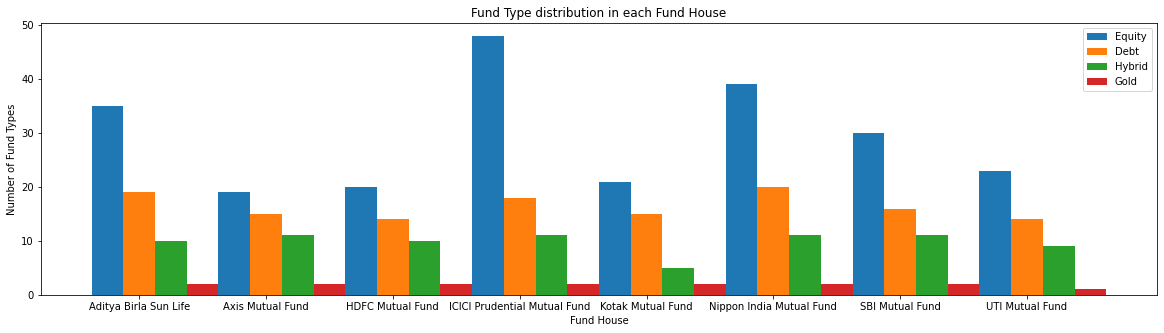

In [28]:
# Generates Figure 3.4

fund_type_by_fundhouse(df_mfs)

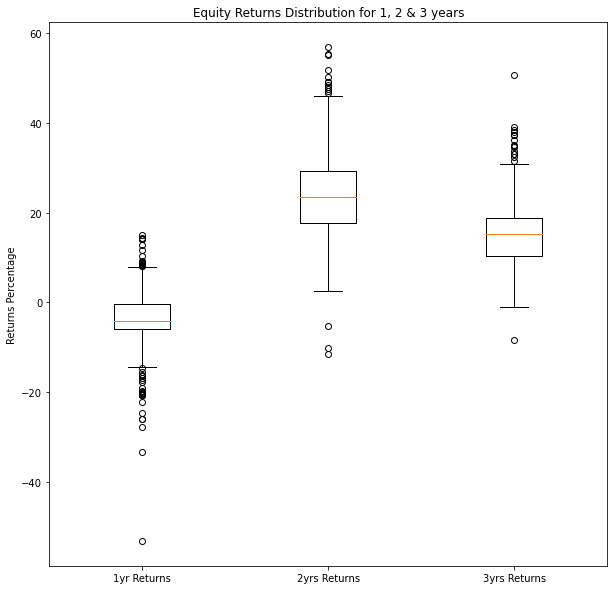

In [29]:
# Generates Figure 3.5

# Equity Returns Distribution for 1, 2 and 3 years

df_mfs_equity_1yr = df_mfs[df_mfs.FundType == 'Equity']['Return (%)1 yr']
df_mfs_equity_2yrs = df_mfs[df_mfs.FundType == 'Equity']['Return (%)2 yrs']
df_mfs_equity_3yrs = df_mfs[df_mfs.FundType == 'Equity']['Return (%)3 yrs']

df_mfs_debt = df_mfs[df_mfs.FundType == 'Debt']
df_mfs_hybrid = df_mfs[df_mfs.FundType == 'Hybrid']
df_mfs_fofs = df_mfs[df_mfs.FundType == 'Fund of Funds']
df_mfs_gold = df_mfs[df_mfs.FundType == 'Gold']

data = [df_mfs_equity_1yr, df_mfs_equity_2yrs, df_mfs_equity_3yrs]

fig = plt.figure(figsize =(10, 10))
xlabel = ['1yr Returns', '2yrs Returns', '3yrs Returns']
plt.boxplot(data)
plt.xticks([1,2,3], xlabel)
plt.ylabel('Returns Percentage')
plt.title('Equity Returns Distribution for 1, 2 & 3 years')
plt.show()

In [30]:
# Function to generate returns performance across each fund type

def fund_type_performance(column):
    '''
    Arguments:
    column - Returns for a particular period  (For e.g, 1 year, 2 years, 3 years)
    
    '''
        
    df_mfs_fundtype_performance = df_mfs.groupby('FundType').agg({column: ['mean', 'max', 'min']})
    df_mfs_fundtype_performance.columns = ['Fund Type Average %', 'Top Performer %','Bottom Performer %'] 
    print('Performance of the Funds per type (Equity, Debt, Hybrid, Fund of Funds, Gold): ')
    df_mfs_fundtype_performance.sort_values('Top Performer %', ascending = False,  inplace = True)
    display(df_mfs_fundtype_performance.round(decimals = 2))
    

In [31]:
# Generates Table 3.1

fund_type_performance('Return (%)2 yrs')

Performance of the Funds per type (Equity, Debt, Hybrid, Fund of Funds, Gold): 


,Fund Type Average %,Top Performer %,Bottom Performer %
FundType,,,
Equity,24.44,56.92,-11.43
Hybrid,12.71,52.82,0.0
Fund of Funds,10.33,47.45,-21.17
Debt,4.26,34.2,-35.98
Gold,-1.59,-0.56,-2.07


In [32]:
# Function to generate returns performance across each fund category

def category_performance(df, fundtype, column):
    '''
    Arguments:
    df - Mutual fund dataframe
    fundtype - Type of Fund (Equity, Debt..)
    column - Returns for a particular period  (For e.g, 1 year, 2 years, 3 years)
    
    '''
        
    df = df[df.FundType == fundtype]
    df = df.groupby(['Fund Category']).agg({column: ['mean', 'max', 'min']})
    df.columns = ['Category Average ' + column, 'Top Performer ' + column, 'Bottom Performer  ' + column]
    df = df.round(decimals = 2)
    df = df.sort_values(by = ['Category Average ' + column], ascending = False)
    if column == "Return (%)1 yr":
        text = 'year to date'
    elif column == "Return (%)2 yrs":
        text = 'last 2 years'
    print('Performance of the different Fund category in ' + fundtype + ' for ' + text + ': ')
    display(df.sort_values('Top Performer ' + column, ascending = False))


In [33]:
# Generates Table 3.2 & 3.3

category_performance(df_mfs, "Equity", "Return (%)2 yrs")

Performance of the different Fund category in Equity for last 2 years: 


,Category Average Return (%)2 yrs,Top Performer Return (%)2 yrs,Bottom Performer Return (%)2 yrs
Fund Category,,,
Sectoral - Infrastructure,40.71,56.92,28.66
ETFs,22.45,55.28,-11.43
Small Cap,38.16,49.12,13.74
Thematic,22.23,48.46,13.74
Tax Saving (ELSS),24.44,46.01,11.68
Mid Cap,31.5,45.9,13.74
Value / Contra,26.03,43.66,13.74
Flexi Cap,23.08,43.44,13.74
Multi Cap,23.82,43.22,13.74


In [34]:
# Generates Table 3.2 & 3.3

category_performance(df_mfs, "Debt", "Return (%)1 yr")

Performance of the different Fund category in Debt for year to date: 


,Category Average Return (%)1 yr,Top Performer Return (%)1 yr,Bottom Performer Return (%)1 yr
Fund Category,,,
Low Duration,4.79,37.14,2.96
Dynamic Bond,-1.01,31.9,-59.01
Medium Duration,-0.7,23.68,-59.02
Short Duration,3.05,17.59,1.05
Ultra Short Duration,3.93,13.69,2.06
Credit Risk,0.31,10.98,-59.02
Banking & PSU,2.43,9.03,0.29
Gilt,1.69,8.8,0.42
Medium to Long Duration,1.3,8.33,-0.4


In [35]:
# Execute the function to generate top performing funds in each category

df_mfs_equity = df_mfs[df_mfs.FundType == 'Equity']
df_mfs_equity_top10 = df_mfs_equity.nlargest(10, 'Return (%)1 yr')
display(df_mfs_equity_top10[["Fund House", "FundType", "Funds", "Inception Date", 'NAV ', 'Return (%)1 yr']])


,Fund House,FundType,Funds,Inception Date,NAV,Return (%)1 yr
873,Motilal Oswal Mutual Fund,Equity,Motilal Oswal Midcap Fund-Reg(G),2014-02-24,52.26,15.04
1054,SBI Mutual Fund,Equity,SBI Consumption Opp Fund-Reg(G),2013-01-01,208.24,14.38
946,Nippon India Mutual Fund,Equity,Nippon India ETF Nifty PSU Bank BeES,2007-10-25,34.97,14.17
733,Kotak Mutual Fund,Equity,Kotak Nifty PSU Bank ETF,2007-11-08,313.38,14.14
1024,Quant Mutual Fund,Equity,Quant ESG Equity Fund-Reg(G),2020-11-05,21.52,14.09
224,Nippon India Mutual Fund,Equity,CPSE ETF,2014-03-28,36.45,12.74
1033,Quant Mutual Fund,Equity,Quant Quantamental Fund-Reg(G),2021-04-30,12.93,11.6
921,Nippon India Mutual Fund,Equity,Nippon India Consumption Fund(G),2004-09-30,132.23,10.31
361,HDFC Mutual Fund,Equity,HDFC Focused 30 Fund(G),2004-09-17,128.4,9.22
1027,Quant Mutual Fund,Equity,Quant Infrastructure Fund(G),2007-08-26,22.82,8.99


### Mutual Fund Statistics

In [36]:
# Mutual Fund column statistics

columns = []
means = []
standard_dev = []
medians = []

data = [df_mfs]

for i in data: 
    for cols in i:
        if type(i[cols][0]) == np.float64:
            columns.append(cols)
            means.append(df_mfs[cols].mean())
            medians.append(df_mfs[cols].median())
            standard_dev.append(df_mfs[cols].std())

df_mf_stats = pd.DataFrame()
df_mf_stats['MF Features'] = columns
df_mf_stats['Mean'] = means 
df_mf_stats['Median'] = medians 
df_mf_stats['Standard Deviation'] = standard_dev 

df_mf_stats

,MF Features,Mean,Median,Standard Deviation
0,AUM(in Rs. cr),3336.532866,702.700,7794.822501
1,ExpenseRatio (%),1.395044,1.515,0.829250
2,NAV,311.790149,36.180,755.393691
3,52 WeekHigh (NAV),329.000394,37.640,782.758744
4,52 WeekLow (NAV),292.177143,33.160,722.473583
5,Return (%)1 mo,-0.510920,-0.160,2.231359
6,Return (%)3 mo,4.337748,4.040,4.922940
7,Return (%)6 mo,0.661578,1.770,6.378835
8,Return (%)1 yr,-1.745478,0.160,8.053412
9,Return (%)2 yrs,14.938317,13.740,12.395697


In [37]:
# Create a dataframe containing all the returns columns

df_mfs_returns = df_mfs[['Funds', 'FundType', 'Fund Category','Return (%)1 mo', 'Return (%)3 mo', 'Return (%)6 mo', 
                         'Return (%)1 yr', 'Return (%)2 yrs', 'Return (%)3 yrs', "category_average_return_1year", 
                         "category_average_return_3years"]].copy()

In [38]:
# Create a dataframe containing all the financial ratios

df_mfs_ratios = df_mfs[['Funds', 'FundType', 'Fund Category', 'ExpenseRatio (%)', 'Turnover Ratio (%)', 'Alpha','Sharpe', 'Sortino', 'Beta', 
                        'Standard Deviation']].copy()

In [39]:
# Combining returns & ratio columns in a new dataframe

frames = [df_mfs_returns, df_mfs_ratios]
df_mfs_returns_with_ratios = pd.concat([df_mfs_returns, df_mfs_ratios], axis = 1, join = 'inner')
df_mfs_returns_with_ratios = df_mfs_returns_with_ratios.loc[:,~df_mfs_returns_with_ratios.columns.duplicated()]


In [40]:
# Checking for missing value percentages in the newly create dataframe

find_missing_values_percentage(df_mfs_returns_with_ratios)

,% of Missing Values


# Unsupervised analysis

## K-means Clustering

In [41]:
def perform_kmeans_clustering(df):
    '''
    Arguments:
    df - Mutual fund dataframe
        
    '''
    
#Feature Scaling - Robust scaling done to manage outliers
    sc_df_mfs_kmeans = RobustScaler()
    df_mfs_kmeans_std = sc_df_mfs_kmeans.fit_transform(df.iloc[:,4:])

# Identify the number of cluster using Elbow method  
    wcss = []
    for i in range(1,11):
        kmeans = KMeans(n_clusters = i, init="random", n_init=10, max_iter=300, random_state = 42)
        kmeans.fit(df.iloc[:,4:].values)
        wcss.append(kmeans.inertia_)
   
    plt.plot(range(1,11), wcss)
    plt.title('The Elbow method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()    
    
#Clustering with KMeans
    kmeans = KMeans(init="k-means++", n_clusters=3, n_init=10, max_iter=300, random_state=42)
    model_kmeans = kmeans.fit_predict(df_mfs_kmeans_std)

# Kmeans metrics
    score = metrics.silhouette_score(df_mfs_kmeans_std, kmeans.labels_, random_state=10)
    df['Cluster'] = kmeans.labels_
    
# Plotting the clusters
    fig, ax = plt.subplots(figsize=(10,7))
    plt.scatter(df_mfs_kmeans["Beta"][df_mfs_kmeans["Cluster"] == 0], 
                df_mfs_kmeans["Standard Deviation"][df_mfs_kmeans["Cluster"] == 0], 
                color = "blue", s=100, edgecolor='green',linestyle='--')

    plt.scatter(df_mfs_kmeans["Beta"][df_mfs_kmeans["Cluster"] == 1], 
                df_mfs_kmeans["Standard Deviation"][df_mfs_kmeans["Cluster"] == 1], 
                color = "red", s=100, edgecolor='green',linestyle='--')

    plt.scatter(df_mfs_kmeans["Beta"][df_mfs_kmeans["Cluster"] == 2], 
                df_mfs_kmeans["Standard Deviation"][df_mfs_kmeans["Cluster"] == 2], 
                color = "green", s=100, edgecolor='green',linestyle='--')


    print("Clustering performance")
    print("-----------------------------------")
    print("Silhouette score: " + str(score.round(2)))



C:\Users\aksha\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


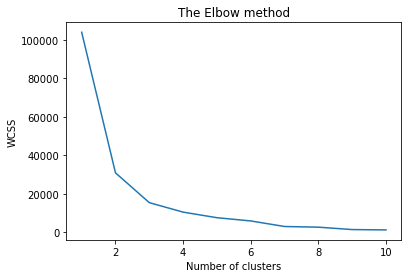

Clustering performance
-----------------------------------
Silhouette score: 0.64


C:\Users\aksha\AppData\Local\Temp\ipykernel_27344\452493349.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = kmeans.labels_


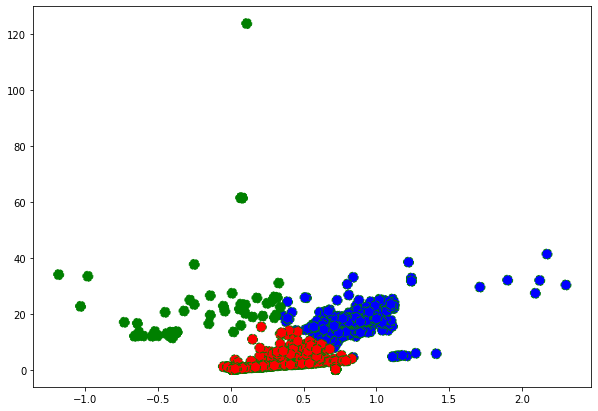

In [42]:
# Generate Figure 4.1.1 & 4.1.2

df_mfs_kmeans = df_mfs_returns_with_ratios[['Funds', 'FundType', 'Fund Category', 'Return (%)2 yrs', 'Beta','Standard Deviation']]
perform_kmeans_clustering(df_mfs_kmeans)

In [43]:
#  Generate data displays from the clusters

# Generate Table 4.1.1, 4.1.2, 4.1.3, 4.1.4, 4.1.5, 4.1.6, 4.1.7

df_cluster_performance_FundType = (df_mfs_kmeans.groupby(['Cluster', 'FundType']).agg({'Funds':"count", 'Beta':"mean", 'Standard Deviation':"mean"})
                       .sort_values('Cluster').reset_index())
df_cluster_performance_Funds = (df_mfs_kmeans.groupby(['Cluster']).agg({'Funds':"count", 'Beta':"mean", 'Standard Deviation':"mean"})
                       .sort_values('Cluster').reset_index())
display(df_cluster_performance_FundType)
display(df_cluster_performance_Funds)
    
display(df_mfs_kmeans[(df_mfs_kmeans.Cluster == 0) & (df_mfs_kmeans.FundType == 'Debt')])
display(df_mfs_kmeans[(df_mfs_kmeans.Cluster == 0) & (df_mfs_kmeans.FundType == 'Equity')].nlargest(10, 'Beta'))
display(df_mfs_kmeans[(df_mfs_kmeans.Cluster == 0) & (df_mfs_kmeans.FundType == 'Hybrid')].nlargest(10, 'Beta').sort_values('Return (%)2 yrs'))
display(df_mfs_kmeans[(df_mfs_kmeans.Cluster == 1) & (df_mfs_kmeans.FundType == 'Hybrid')].nlargest(10, 'Beta').sort_values('Return (%)2 yrs'))
display(df_mfs_kmeans[(df_mfs_kmeans.Cluster == 0) & (df_mfs_kmeans.FundType == 'Hybrid')].
            groupby(['Fund Category']).agg({'Funds':"count"}))
display(df_mfs_kmeans[(df_mfs_kmeans.Cluster == 1) & (df_mfs_kmeans.FundType == 'Hybrid')].
            groupby(['Fund Category']).agg({'Funds':"count"}))

,Cluster,FundType,Funds,Beta,Standard Deviation
0,0,Debt,13,1.000769,8.323846
1,0,Equity,501,0.895908,18.464271
2,0,Fund of Funds,46,0.898913,19.911522
3,0,Hybrid,70,0.81,13.577143
4,1,Debt,325,0.293692,1.210708
5,1,Fund of Funds,29,0.388966,5.798966
6,1,Hybrid,100,0.3445,4.8826
7,2,Debt,7,0.062857,59.178571
8,2,Equity,9,0.096667,23.83
9,2,Fund of Funds,19,-0.161053,23.445263


,Cluster,Funds,Beta,Standard Deviation
0,0,630,0.888746,17.817683
1,1,454,0.310969,2.312577
2,2,57,-0.203509,24.054561


,Funds,FundType,Fund Category,Return (%)2 yrs,Beta,Standard Deviation,Cluster
47,Aditya Birla SL Medium Term Plan-Reg(G),Debt,Medium Duration,15.21,0.56,15.97,0
198,BHARAT Bond ETF - April 2032,Debt,ETFs,13.74,0.72,14.7,0
225,DSP 10Y G-Sec Fund-Reg(G),Debt,Gilt (10 Yr Constant Duration),0.01,1.14,4.9,0
443,ICICI Pru Constant Maturity Gilt Fund(G),Debt,Gilt (10 Yr Constant Duration),1.63,1.15,4.91,0
468,ICICI Pru Long Term Bond Fund(G),Debt,Long Duration,0.62,1.21,4.87,0
585,IDFC G-Sec-Constant Maturity Plan-Reg(G),Debt,Gilt (10 Yr Constant Duration),1.02,1.16,4.98,0
784,LIC MF Gsec Long Term ETF,Debt,ETFs,0.87,1.12,4.63,0
937,Nippon India ETF Nifty 8-13 yr G-Sec Long Term...,Debt,ETFs,0.82,1.14,4.72,0
976,Nippon India Nivesh Lakshya Fund(G),Debt,Long Duration,2.17,1.41,5.69,0
1032,Quant Multi Asset Fund(G),Debt,Gilt,34.2,0.39,18.44,0


,Funds,FundType,Fund Category,Return (%)2 yrs,Beta,Standard Deviation,Cluster
853,Mirae Asset NYSE FANG+ ETF,Equity,ETFs,13.74,2.17,41.37,0
733,Kotak Nifty PSU Bank ETF,Equity,ETFs,55.09,1.24,31.7,0
946,Nippon India ETF Nifty PSU Bank BeES,Equity,ETFs,55.28,1.24,31.69,0
503,ICICI Pru Nifty Private Bank ETF,Equity,ETFs,25.24,1.12,23.15,0
540,IDBI Banking & Financial Services Fund-Reg(G),Equity,Sectoral - Financial Services,21.39,1.12,21.93,0
1024,Quant ESG Equity Fund-Reg(G),Equity,Thematic,13.74,1.12,24.24,0
1101,SBI Nifty Private Bank ETF,Equity,ETFs,25.02,1.12,23.11,0
1187,Tata Nifty Pvt Bank ETF,Equity,ETFs,25.44,1.12,23.03,0
480,ICICI Pru Nifty 100 Low Volatility 30 ETF FOF(G),Equity,ETFs,13.74,1.11,15.57,0
847,Mirae Asset Nifty Financial Services ETF,Equity,ETFs,13.74,1.11,21.91,0


,Funds,FundType,Fund Category,Return (%)2 yrs,Beta,Standard Deviation,Cluster
982,Nippon India Retirement Fund-Income Generation(G),Hybrid,Solution Oriented,4.65,1.27,5.86,0
3,Aditya Birla SL Bal Bhavishya Yojna-Reg(G),Hybrid,Solution Oriented,12.91,1.03,16.61,0
77,Aditya Birla SL Retirement Fund-30-Reg(G),Hybrid,Solution Oriented,13.58,0.98,16.13,0
137,Axis Retirement Savings Fund-Aggressive Plan-R...,Hybrid,Solution Oriented,13.6,1.04,14.09,0
778,LIC MF Childrens Gift Fund(G),Hybrid,Solution Oriented,13.69,0.96,15.05,0
1194,Tata Retirement Sav Fund - Prog Plan(G),Hybrid,Solution Oriented,15.38,0.97,16.9,0
232,DSP Equity & Bond Fund-Reg(G),Hybrid,Equity Oriented,17.9,0.96,13.61,0
24,Aditya Birla SL Equity Hybrid 95 Fund(G),Hybrid,Equity Oriented,18.69,1.08,14.06,0
983,Nippon India Retirement Fund-Wealth Creation(G),Hybrid,Solution Oriented,24.17,1.06,17.94,0
1241,UTI CCF- Investment Plan(G),Hybrid,Solution Oriented,24.77,0.98,17.59,0


,Funds,FundType,Fund Category,Return (%)2 yrs,Beta,Standard Deviation,Cluster
1151,Tata Arbitrage Fund-Reg(G),Hybrid,Arbitrage,3.75,0.72,0.86,1
426,HSBC Regular Savings Fund(G),Hybrid,Debt Oriented (Conservative),6.42,0.76,5.09,1
395,HDFC Retirement Savings Fund-Hybrid-Debt Plan-...,Hybrid,Solution Oriented,7.6,0.71,3.84,1
231,DSP Dynamic Asset Allocation Fund-Reg(G),Hybrid,Dynamic Asset Allocation,8.45,0.61,7.27,1
337,Franklin India Pension Plan(G),Hybrid,Solution Oriented,9.37,0.63,6.92,1
1123,Sundaram Balanced Advantage Fund(G),Hybrid,Dynamic Asset Allocation,9.63,0.62,9.06,1
1116,Shriram Balanced Advantage Fund-Reg(G),Hybrid,Dynamic Asset Allocation,10.07,0.61,8.15,1
1284,UTI ULIP(G),Hybrid,Debt Oriented (Balanced),11.06,0.68,7.36,1
1107,SBI Retirement Benefit Fund-Conservative Hybri...,Hybrid,Solution Oriented,13.74,0.66,7.22,1
1108,SBI Retirement Benefit Fund-Conservative Plan-...,Hybrid,Solution Oriented,13.74,0.61,3.98,1


,Funds
Fund Category,
Dynamic Asset Allocation,9
Equity Oriented,34
Multi Asset Allocation,3
Solution Oriented,24


,Funds
Fund Category,
Arbitrage,25
Debt Oriented (Balanced),1
Debt Oriented (Conservative),19
Dynamic Asset Allocation,12
Equity Oriented,23
Multi Asset Allocation,7
Solution Oriented,13


# Supervised Approach

## Linear Regression

#### Checking correlation of 1 year returns with the different ratios

<AxesSubplot:>

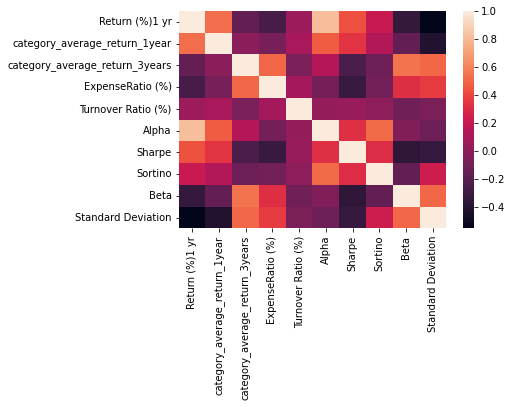

In [44]:
# Generates Figure 5.1.1

df_mfs_returns_1yr = df_mfs_returns_with_ratios.drop(['Return (%)1 mo', 'Return (%)3 mo', 'Return (%)6 mo', 'Return (%)2 yrs', 
                                                     'Return (%)3 yrs'], axis = 1)
sns.heatmap(df_mfs_returns_1yr.corr())


#### Checking correlation of 2 years returns with the different ratios

<AxesSubplot:>

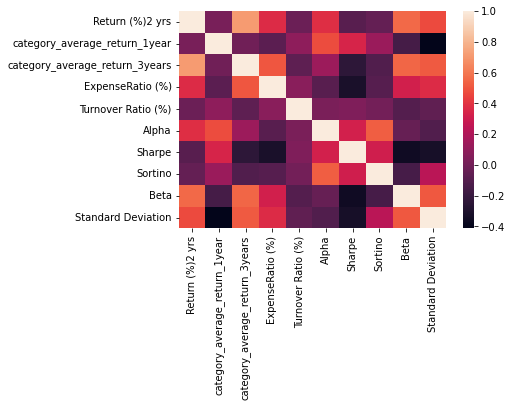

In [45]:
# Generates Figure 5.1.2

df_mfs_returns_2yrs = df_mfs_returns_with_ratios.drop(['Return (%)1 mo', 'Return (%)3 mo', 'Return (%)6 mo', 'Return (%)1 yr', 
                                                     'Return (%)3 yrs'], axis = 1)
sns.heatmap(df_mfs_returns_2yrs.corr())

#### Checking correlation of 3 years returns with the different ratios

<AxesSubplot:>

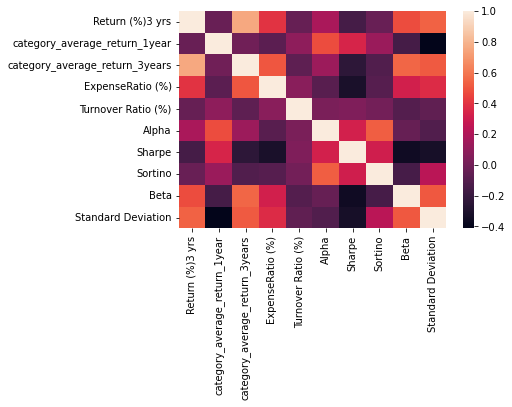

In [46]:
# Generates Figure 5.1.3

df_mfs_returns_3yrs = df_mfs_returns_with_ratios.drop(['Return (%)1 mo', 'Return (%)3 mo', 'Return (%)6 mo', 'Return (%)1 yr', 
                                                     'Return (%)2 yrs'], axis = 1)
sns.heatmap(df_mfs_returns_3yrs.corr())

#### Identify important ratios affecting the returns

In [47]:
# Identify the important ratios affecting the returns

def ratio_score(predictors, output):
    '''
    Arguments:
    predictors - Independent variable which is ratios here
    output - Dependent variable which is the returns for a specific period    
    '''
    ratio_model = RandomForestRegressor()
    x = predictors
    y = output
    ratio_model.fit(x,y)
    df_mf_features = pd.DataFrame(np.array(ratio_model.feature_importances_).T, index = x.columns, 
                              columns = ['ratio_score']).sort_values(ascending = False, by = 'ratio_score')
    df_mf_features['correlations'] = df_mfs_returns_2yrs.corr()['Return (%)2 yrs'].drop(['Return (%)2 yrs'])
    display(df_mf_features)
    

In [48]:
# Generates Table 5.1.1

# Identify the important ratios in case of 1 year returns

ratios = df_mfs_returns_1yr[['ExpenseRatio (%)', 'Turnover Ratio (%)', 'Alpha','Sharpe', 'Sortino', 'Beta', 'Standard Deviation']]
return_1yr = df_mfs_returns_1yr['Return (%)1 yr']
ratio_score(ratios, return_1yr)

,ratio_score,correlations
Alpha,0.689160,0.376445
Sortino,0.159333,-0.044889
Standard Deviation,0.087698,0.467433
Sharpe,0.037977,-0.092556
Turnover Ratio (%),0.009974,-0.025571
Beta,0.008974,0.554701
ExpenseRatio (%),0.006883,0.369417


In [49]:
# Generates Table 5.1.2

# Identify the important ratios in case of 2 years returns

ratios = df_mfs_returns_2yrs[['ExpenseRatio (%)', 'Turnover Ratio (%)', 'Alpha','Sharpe', 'Sortino', 'Beta', 'Standard Deviation']]
return_2yr = df_mfs_returns_2yrs['Return (%)2 yrs']
ratio_score(ratios, return_2yr)

,ratio_score,correlations
Beta,0.410223,0.554701
Standard Deviation,0.208739,0.467433
Alpha,0.166838,0.376445
Sortino,0.102729,-0.044889
Turnover Ratio (%),0.040825,-0.025571
Sharpe,0.038143,-0.092556
ExpenseRatio (%),0.032503,0.369417


In [50]:
# Generates Table 5.1.3

# Identify the important ratios in case of 3 years returns

ratios = df_mfs_returns_3yrs[['ExpenseRatio (%)', 'Turnover Ratio (%)', 'Alpha','Sharpe', 'Sortino', 'Beta', 'Standard Deviation']]
return_3yr = df_mfs_returns_3yrs['Return (%)3 yrs']
ratio_score(ratios, return_3yr)

,ratio_score,correlations
Standard Deviation,0.528212,0.467433
Alpha,0.113084,0.376445
Beta,0.111835,0.554701
ExpenseRatio (%),0.093020,0.369417
Turnover Ratio (%),0.062712,-0.025571
Sortino,0.061062,-0.044889
Sharpe,0.030074,-0.092556


### Performing Linear Regression to predict the 1yr, 2 yrs & 3 yrs returns based on the different ratios

In [51]:
# Function defined to perform a linear regression for predicting the different types of returns based on the different ratios

def lin_regression(predictors, output, text):
    '''
    Arguments:
    predictors: These are the independent variables  (here, it will be a ratio)
    output: This is the dependent variable (here, it will be a return for certain period)
    text: Tells the number of years
    
    '''
    x = predictors.values.reshape(-1, 1)
    y = output.values
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)
    model = LinearRegression()
    model.fit(x_train, y_train)
    print('Score of the model: ', model.score(x_test,y_test)) 
    
# Coefficients calculated by the linear regression
    print('Coefficients: ', model.coef_)
    
# Intercept calculated by the linear regression
    print('Intercept: ', model.intercept_)

# Predict  
    y_pred = model.predict(x_test)
    
# Plotting the straight line
    plt.figure(figsize=(12, 6))
    plt.plot(x_test, y_pred)     # regression line
    plt.plot(x_test, y_test, 'ro')   # scatter plot showing actual data
    plt.title('Actual vs Predicted', fontsize=20)
    plt.xlabel('Ratio: ' + predictors.columns[0], fontsize=12)
    if text == '1 year':
        plt.ylabel('1 year returns', fontsize=12)
    elif text == '2 years':
        plt.ylabel('2 years returns', fontsize=12)
    else:
        plt.ylabel('3 years returns', fontsize=12)
        
    plt.figtext(0, 0.8, 'Score: ' + str(round(model.score(x_test,y_test),2)), fontsize=11)
    plt.figtext(0, 0.75, 'MAE: ' + str(round(metrics.mean_absolute_error(y_test, y_pred),2)), fontsize=11)
    plt.figtext(0, 0.70, 'MSE: ' + str(round(metrics.mean_squared_error(y_test, y_pred),2)), fontsize=11)
    plt.figtext(0, 0.65, 'RMSE: ' + str(round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)),2)), fontsize=11)


Score of the model:  0.13266194830911504
Coefficients:  [0.86760549]
Intercept:  -0.5395354649344601


C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.

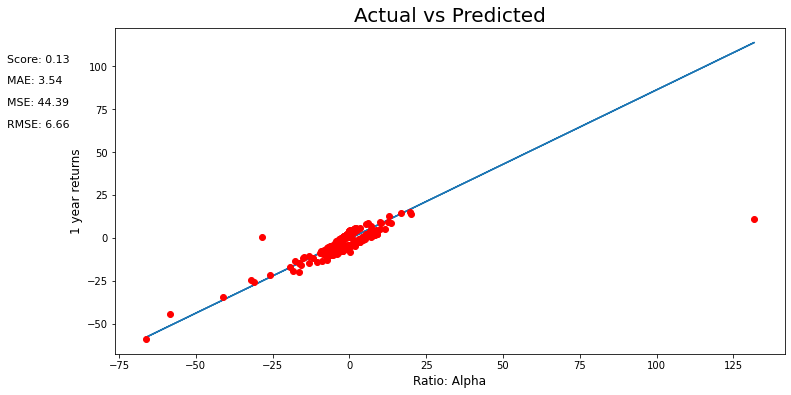

In [52]:
# Generates Figure 5.1.4 & 5.1.5

ratios = df_mfs_returns_1yr[['Alpha']]

return_1yr = df_mfs_returns_1yr['Return (%)1 yr']
lin_regression(ratios, return_1yr, '1 year')

Score of the model:  0.3588342873024084
Coefficients:  [16.27721849]
Intercept:  5.339874197403239


C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.

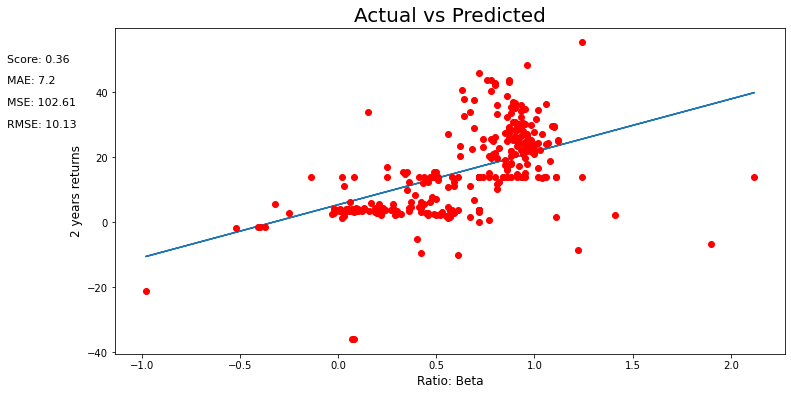

In [53]:
# Generates Figure 5.1.6

ratios = df_mfs_returns_2yrs[['Beta']]

return_2yrs = df_mfs_returns_2yrs['Return (%)2 yrs']
lin_regression(ratios, return_2yrs, '2 years')

Score of the model:  0.16833036737270224
Coefficients:  [0.43019279]
Intercept:  6.015119769513822


C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.

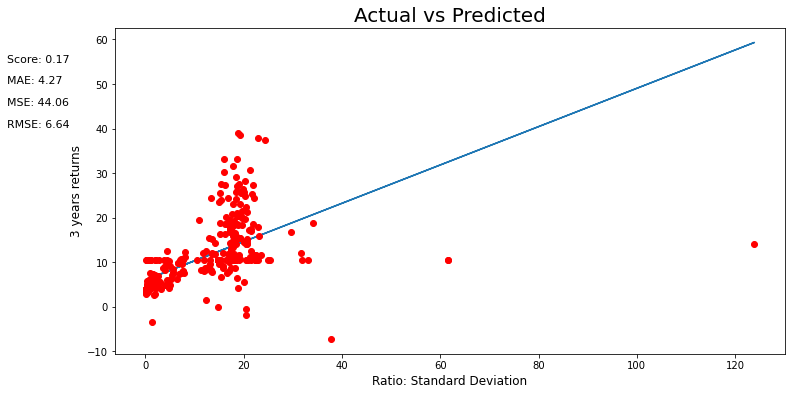

In [54]:
# Generates Figure 5.1.7

ratios = df_mfs_returns_3yrs[['Standard Deviation']]

return_3yrs = df_mfs_returns_3yrs['Return (%)3 yrs']
lin_regression(ratios, return_3yrs, '3 years')

## Logistic Regression

In [55]:
# Returns 0 or 1 depending if fund return is above category average and creates a new col

def greater_than_category_average(df,parameter):
    '''
    This function checks whether the return in a certain time frame is above the category average
    
    Arguments:
    df: Contains both fund and categorical return data
    parameter: Time period to compare return data
    '''
    category="category_average_return_"+ parameter
    if parameter == '1year':
        fund = "Return (%)1 yr"
    else:
        fund = "Return (%)3 yrs"
        
    newcol="score_average_" +parameter
    
    cat_idx= df.columns.get_loc(category)
    fund_idx= df.columns.get_loc(fund)
    
    greater_list = []
    for i in range(df.shape[0]):
        if(df.iloc[i,fund_idx]>df.iloc[i,cat_idx] ):
            greater_list.append(1)
        else:
            greater_list.append(0)
    df[newcol]=greater_list
    

In [56]:
# Execute the function to check if the fund returns is above or below category average for 1 year returns

greater_than_category_average(df_mfs_returns_1yr,'1year')
display(df_mfs_returns_1yr[['Funds', 'FundType', 'Fund Category', 'Return (%)1 yr', 'category_average_return_1year', 
                            'score_average_1year']])


,Funds,FundType,Fund Category,Return (%)1 yr,category_average_return_1year,score_average_1year
0,Aditya Birla SL Active Debt Multi-Mgr FoF(G),Fund of Funds,Domestic,2.24,-3.72,1
1,Aditya Birla SL Arbitrage Fund(G),Hybrid,Arbitrage,3.64,3.56,1
2,Aditya Birla SL Asset Allocator FoF(G),Fund of Funds,Domestic,-1.97,-3.72,1
3,Aditya Birla SL Bal Bhavishya Yojna-Reg(G),Hybrid,Solution Oriented,-4.97,-1.53,0
4,Aditya Birla SL Balanced Advantage Fund(G),Hybrid,Dynamic Asset Allocation,-0.56,1.18,0
...,...,...,...,...,...,...
1286,UTI Value Opp Fund-Reg(G),Equity,Value / Contra,-3.12,3.04,0
1287,UTI-Nifty Next 50 ETF,Equity,ETFs,-5.03,-3.32,0
1289,WOC Liquid Fund-Reg(G),Debt,Liquid,3.76,4.1,0
1291,WOC Overnight Fund-Reg(G),Debt,Overnight,3.91,4.1,0


In [57]:
# Execute the function to check if the fund returns is above or below category average for 1 year returns

greater_than_category_average(df_mfs_returns_3yrs,'3years')
display(df_mfs_returns_3yrs[['Funds', 'FundType', 'Fund Category', 'Return (%)3 yrs', 'category_average_return_3years', 
                             'score_average_3years']])


,Funds,FundType,Fund Category,Return (%)3 yrs,category_average_return_3years,score_average_3years
0,Aditya Birla SL Active Debt Multi-Mgr FoF(G),Fund of Funds,Domestic,5.54,13.95,0
1,Aditya Birla SL Arbitrage Fund(G),Hybrid,Arbitrage,3.94,3.65,1
2,Aditya Birla SL Asset Allocator FoF(G),Fund of Funds,Domestic,13.97,13.95,1
3,Aditya Birla SL Bal Bhavishya Yojna-Reg(G),Hybrid,Solution Oriented,9.56,19.02,0
4,Aditya Birla SL Balanced Advantage Fund(G),Hybrid,Dynamic Asset Allocation,11.02,10.47,1
...,...,...,...,...,...,...
1286,UTI Value Opp Fund-Reg(G),Equity,Value / Contra,18.66,21.88,0
1287,UTI-Nifty Next 50 ETF,Equity,ETFs,15.3,12.35,1
1289,WOC Liquid Fund-Reg(G),Debt,Liquid,3.58,3.86,0
1291,WOC Overnight Fund-Reg(G),Debt,Overnight,3.48,3.6,0


### Perform Logistic Regression to predict the outcome of above average returns based on ratios

In [58]:
# Function to perform Logistic regression

def log_regression(predictors, output):
    '''
    This function performs logistic regression analysis
    
    Arguments:
    predictors: Independent variable which is ratios here
    output: 1 or 0 values generated above for comparing with category average returns
    '''
    
    X_train, X_test, y_train, y_test = train_test_split(predictors, output, test_size=0.30, random_state=16)
    
# instantiate the model (using the default parameters)
    logreg = LogisticRegression(random_state=16)
    
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
    display(cnf_matrix)
    class_names=[0,1] 
    fig, ax = plt.subplots()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    
# Create heatmap   
    sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
    ax.xaxis.set_label_position("top")
    plt.tight_layout()
    plt.title('Confusion matrix', y=1.1)
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    target_names = ['Below Average', 'Above Average']
    print(classification_report(y_test, y_pred, target_names=target_names))

# Generating cross-validation scores
    scores = cross_val_score(logreg, X_train, y_train, cv=10)
    print('Cross-Validation Accuracy Scores', scores)

C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


array([[200,  11],
       [107,  25]], dtype=int64)

               precision    recall  f1-score   support

Below Average       0.65      0.95      0.77       211
Above Average       0.69      0.19      0.30       132

     accuracy                           0.66       343
    macro avg       0.67      0.57      0.53       343
 weighted avg       0.67      0.66      0.59       343

Cross-Validation Accuracy Scores [0.6625     0.65       0.6125     0.6375     0.6875     0.6625
 0.6625     0.65       0.67088608 0.69620253]


C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X =

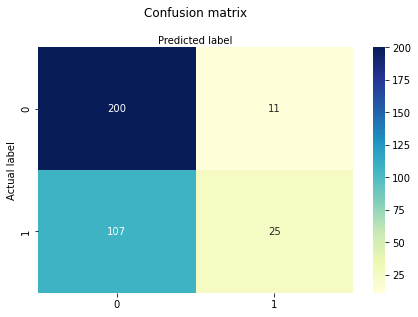

In [59]:
# Generates Table 5.2.1
# Generates Figure 5.2.1

ratios = df_mfs_returns_1yr[['Sharpe']]
greater_than_average_1yr = df_mfs_returns_1yr['score_average_1year']
log_regression(ratios, greater_than_average_1yr)


C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


array([[176,  13],
       [128,  26]], dtype=int64)

               precision    recall  f1-score   support

Below Average       0.58      0.93      0.71       189
Above Average       0.67      0.17      0.27       154

     accuracy                           0.59       343
    macro avg       0.62      0.55      0.49       343
 weighted avg       0.62      0.59      0.51       343

Cross-Validation Accuracy Scores [0.6        0.6125     0.5625     0.6        0.625      0.5875
 0.5625     0.575      0.59493671 0.59493671]


C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)
C:\Users\aksha\anaconda3\lib\site-packages\sklearn\base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X =

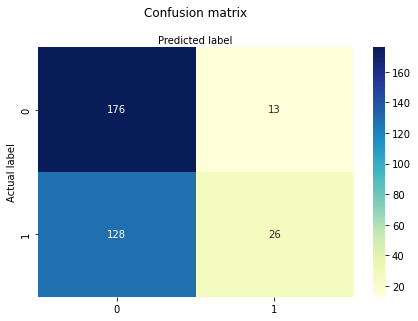

In [60]:
# Generates Table 5.2.2
# Generates Figure 5.2.2

ratios = df_mfs_returns_3yrs[['Sharpe']]
greater_than_average_3yrs = df_mfs_returns_3yrs['score_average_3years']
log_regression(ratios, greater_than_average_3yrs)
